In [15]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [16]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [17]:
X = make_blobs(n_samples=100, centers=3, cluster_std=0.60, random_state=42)
X

(array([[-7.38770342, -7.78901793],
        [ 5.12798917,  1.23465109],
        [-2.79088225,  9.33982215],
        [ 5.48155542,  1.13205905],
        [-6.66495477, -6.54363888],
        [ 4.04555704,  1.63339105],
        [-2.31043956,  9.5996132 ],
        [ 4.5080757 ,  2.18743723],
        [ 4.69812537,  2.55435668],
        [-3.19979377,  9.23970494],
        [-2.83582726,  9.08083968],
        [-6.74315123, -6.09582394],
        [-6.56646225, -6.70191879],
        [-3.17299861,  8.29656215],
        [-2.06611768,  9.1171071 ],
        [-7.52216269, -6.59062614],
        [-6.71361271, -6.38379964],
        [-2.5524037 ,  9.61640587],
        [-7.40994165, -6.78787453],
        [-6.59568462, -6.92380694],
        [-2.78724824,  8.73484828],
        [-6.92588822, -6.67541841],
        [-7.14753616, -6.36627032],
        [-2.29236026,  9.93710807],
        [-2.53069325,  9.95307232],
        [-2.78558089,  9.64855946],
        [ 3.79065639,  1.72078249],
        [-6.50422678, -7.394

In [18]:
X,y = make_blobs(n_samples=500, centers=3, cluster_std=0.60, random_state=42)

In [19]:
df = pd.DataFrame(X, columns=['Feature 1', 'Feature 2'])
df.head()

,Feature 1,Feature 2
0,-6.190063,-7.302015
1,3.021747,1.940593
2,5.953761,1.488191
3,-2.744463,8.136177
4,5.360607,1.728324


In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [21]:
inertia = []
K_range = range(1,11)

In [22]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [23]:
inertia

[1000.0000000000002,
 297.8954141051722,
 11.575484723104982,
 9.752067977356841,
 8.25717527244628,
 6.9175773204168,
 6.334755391595289,
 5.704177177901431,
 5.060234133532077,
 4.762361898130397]

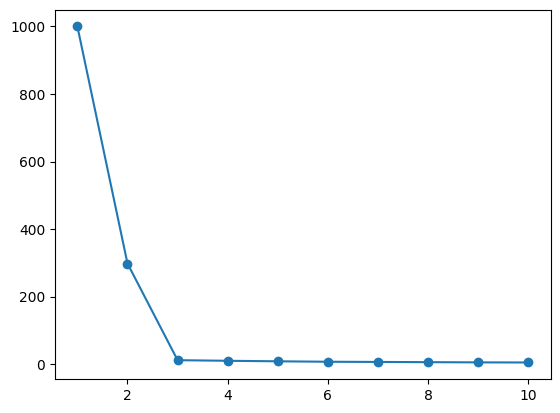

In [24]:
plt.plot(K_range, inertia, marker='o')

In [26]:
Kmeans_final = KMeans(n_clusters=3, random_state=42)
cluster_labels = Kmeans_final.fit_predict(X_scaled)
cluster_labels

array([1, 0, 0, 2, 0, 0, 1, 0, 0, 1, 0, 2, 2, 2, 0, 0, 2, 1, 1, 2, 0, 2,
       0, 1, 1, 0, 0, 1, 1, 2, 0, 2, 2, 2, 0, 0, 0, 0, 1, 1, 0, 2, 2, 2,
       2, 0, 0, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 2, 0, 1, 0, 1,
       0, 1, 2, 0, 0, 0, 0, 1, 2, 1, 2, 0, 2, 2, 1, 2, 0, 2, 1, 1, 1, 1,
       0, 2, 1, 0, 2, 0, 0, 1, 2, 2, 2, 1, 0, 2, 2, 1, 1, 2, 2, 1, 2, 1,
       1, 1, 1, 1, 1, 0, 2, 1, 0, 1, 2, 2, 0, 0, 1, 0, 2, 0, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 2, 1, 1, 0, 0, 1, 1, 1, 2, 2, 2, 0, 1, 0, 0,
       2, 1, 2, 1, 0, 0, 1, 1, 2, 2, 1, 2, 2, 0, 1, 1, 1, 2, 2, 1, 1, 2,
       2, 0, 0, 0, 2, 1, 2, 2, 1, 1, 2, 0, 2, 1, 1, 1, 1, 1, 2, 0, 2, 2,
       1, 0, 2, 2, 1, 1, 0, 1, 0, 2, 2, 1, 1, 0, 1, 2, 2, 1, 2, 1, 2, 0,
       0, 2, 1, 2, 0, 2, 2, 1, 0, 0, 0, 0, 2, 1, 1, 1, 2, 0, 2, 0, 0, 0,
       2, 2, 1, 1, 0, 2, 2, 0, 2, 2, 2, 2, 0, 2, 1, 2, 1, 2, 2, 2, 1, 2,
       0, 0, 0, 2, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 1, 1, 2, 0, 2, 2, 1, 2,
       0, 1, 0, 0, 1, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0,

In [28]:
df['cluster'] = cluster_labels

<Axes: xlabel='Feature 1', ylabel='Feature 2'>

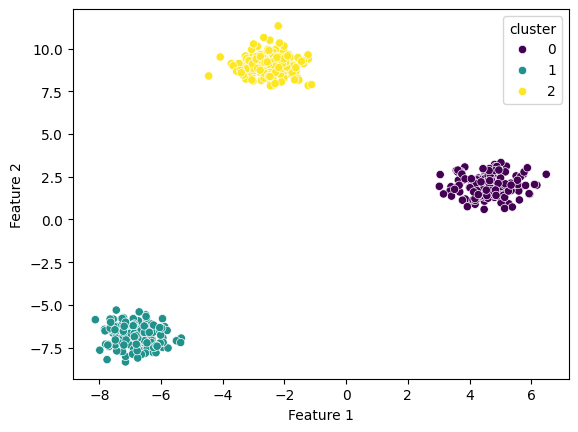

In [29]:
sns.scatterplot(
    x = df['Feature 1'],
    y = df['Feature 2'],
    hue=df['cluster'],
    palette='viridis'                
)